# Wafer 위치별 평균 절대편차
계측값에서 해당 wafer 유효값 평균을 뺀 절대편차를 같은 위치끼리 평균냅니다.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src.detailed_analysis import evaluate_conditions, follow_up_estimate
from src.render_detailed import render
render(ROOT)

## 1. 집계 데이터와 유효 개수
공개 CSV에는 위치별 절대편차 합계와 유효 wafer 수를 포함합니다. 전체 원시 계측값은 공개하지 않았습니다.

In [2]:
points = pd.read_csv(ROOT/'data/wafer_location_error_summary.csv')
points['reproduced_mad'] = points.absolute_deviation_sum / points.valid_wafer_count
assert (points.reproduced_mad - points.mean_absolute_deviation).abs().max() < 1e-5
display(points[['point','valid_wafer_count','absolute_deviation_sum','reproduced_mad']])

,point,valid_wafer_count,absolute_deviation_sum,reproduced_mad
0,1,25,1604.437152,64.177486
1,2,25,2331.170391,93.246816
2,3,25,361.707342,14.468294
3,4,25,2727.156754,109.086270
4,5,25,4633.805589,185.352224
5,6,25,5113.742939,204.549718
6,7,25,3676.102694,147.044108
7,8,25,609.249105,24.369964
8,9,25,2038.780331,81.551213
9,10,25,6397.629497,255.905180


## 2. 원시 데이터부터 계산할 때 사용하는 함수
원본 파일을 가진 경우 `load_measurements`로 조건 번호를 연결하고 `point_deviation`으로 재계산합니다. 다음은 결측 처리 정의를 보여주는 작은 예시이며 실제 공정 결과가 아닙니다.

In [3]:
from src.detailed_analysis import point_deviation
example = pd.DataFrame({'condition_id':[1,1,2,2], 'point':[1,2,1,2], 'thickness':[100.,120.,200.,float('nan')]})
display(point_deviation(example))

,point,valid_wafer_count,absolute_deviation_sum,mean_absolute_deviation
0,1,2,10.0,5.0
1,2,1,10.0,10.0


## 3. 위치별 순위와 49-point map
각 wafer 평균은 현재 유효 두께로 재계산했습니다. 원본 캐시 값과 일부 위치에서 차이가 있지만 49번 최대 결론은 같습니다.

,point,valid_wafer_count,absolute_deviation_sum,mean_absolute_deviation,x_mm,y_mm,workbook_cached_mad,reproduced_mad
48,49,24,10085.179650,420.215819,-37.528762,140.059245,420.215819,420.215819
47,48,24,9917.966107,413.248588,-72.500000,125.573684,413.248588,413.248588
25,26,25,9912.917431,396.516697,0.000000,145.000000,395.387257,396.516697
46,47,23,8880.069660,386.089985,-102.530483,102.530483,386.089985,386.089985
26,27,25,8903.240930,356.129637,37.528762,140.059245,355.000197,356.129637
45,46,24,8030.414743,334.600614,-125.573684,72.500000,334.600614,334.600614
16,17,25,8250.449904,330.017996,38.268343,-92.387953,331.147436,330.017996
17,18,25,7802.284835,312.091393,0.000000,-100.000000,313.220833,312.091393
35,36,25,7469.266998,298.770680,72.500000,-125.573684,299.900120,298.770680
36,37,24,7153.634690,298.068112,37.528762,-140.059245,299.244612,298.068112


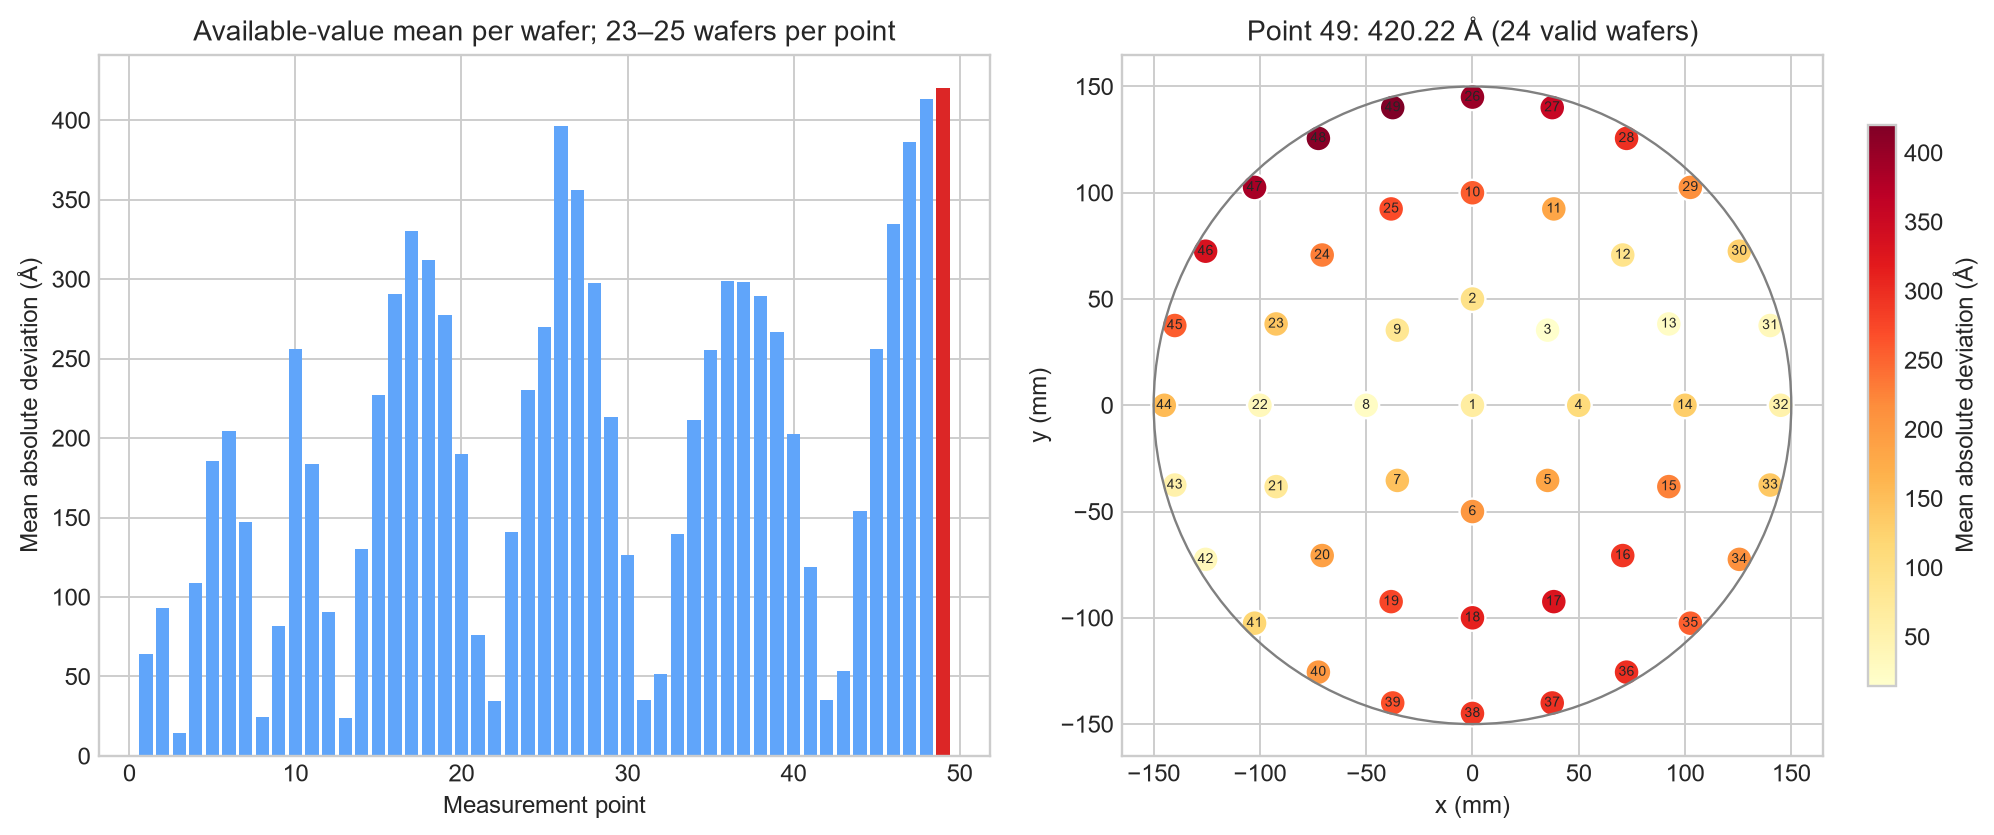

In [4]:
ranking = points.sort_values('reproduced_mad',ascending=False)
display(ranking.head(10))
assert ranking.iloc[0].point == 49
display(Image(filename=str(ROOT/'images/wafer_location_deviation.png')))

## 해석
49번 평균 절대편차 420.22 Å, 유효 wafer 24개. 48번 413.25 Å도 함께 확인할 외곽 위치입니다. 이 지표는 원인이나 불량 확률을 확정하지 않습니다.